# LwF (Learning without Forgetting)

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "main"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [02:53<00:00, 40.3MB/s]

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess data**

In [5]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [6]:
# BASE
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [7]:
# TASK 1
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


In [8]:
# TASK 2
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


In [9]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [10]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']


### Label encoding

In [11]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14}


## **Create Loaders**

In [12]:
base_test = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"), class_to_idx=class_to_idx)
base_test_loader = DataLoader(base_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

## **Upload Model**

In [13]:
model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
model.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
model = unfreeze_all(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 30.1MB/s]


### Expand the head

In [14]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

In [15]:
snapshots = []
results_baseline = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_baseline)

  base             -> Acc=0.9387  Loss=0.1979
  task1_only        -> Acc=0.0000  Loss=4.4398
  combined_t1       -> Acc=0.6180  Loss=1.6470


In [16]:
print(f"classifier: in={model.fc.in_features}  out={model.fc.out_features}")

classifier: in=256  out=15


## **Task One**

### Frozen copy of the model

In [17]:
teacher1 = snapshot_teacher(model)

### Training (LwF)

In [18]:
set_seed(cfg.SEED)
forget_hist = []
track1 = {"Base": base_test_loader, "Task 1": task1_test_loader}
train_task1 = train_continual(model, task1_train_loader, task1_val_loader, device,
                              teacher=teacher1, num_old_classes=len(cfg.SELECTED_CLASSES),
                              lambda_distill=cfg.LAMBDA_DISTILL, T=cfg.KD_TEMPERATURE,
                              epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                              track_loaders=track1, track_history=forget_hist)

Epoch [1/5] | Train Acc: 0.1193 Loss: 4.3442 | Val Acc: 0.4658 Loss: 1.3868
Epoch [2/5] | Train Acc: 0.7180 Loss: 2.1906 | Val Acc: 0.9178 Loss: 0.6184
Epoch [3/5] | Train Acc: 0.8785 Loss: 1.5848 | Val Acc: 0.9589 Loss: 0.4235
Epoch [4/5] | Train Acc: 0.9349 Loss: 1.2722 | Val Acc: 0.9452 Loss: 0.3596
Epoch [5/5] | Train Acc: 0.9761 Loss: 1.0024 | Val Acc: 0.9178 Loss: 0.3439


### Training curves

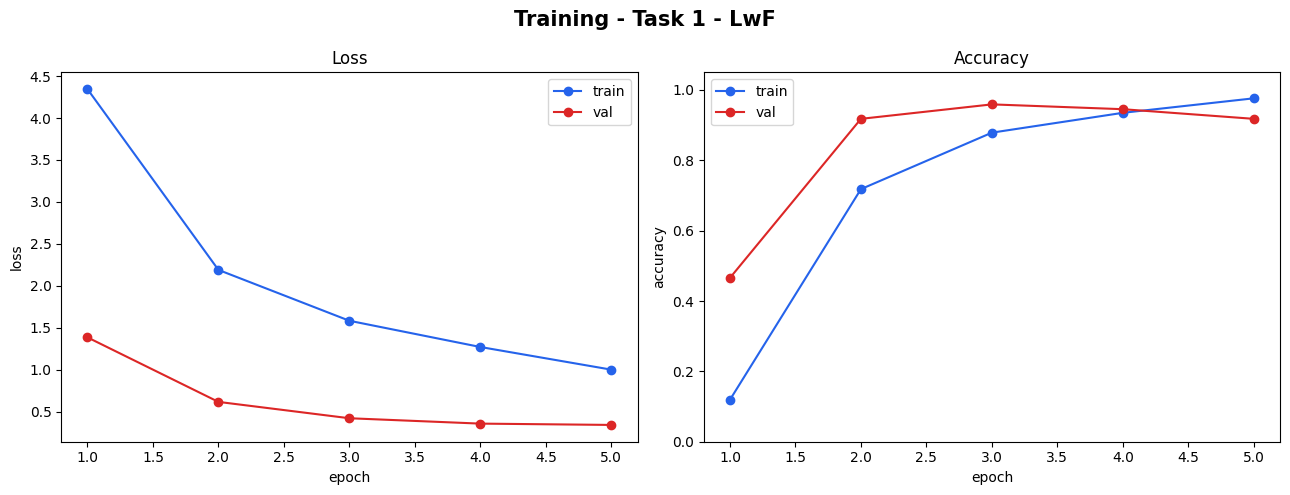

In [19]:
plot_training_results(train_task1, task_name="Task 1 - LwF")

### Evaluate all tasks

In [20]:
results_after_t1 = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_after_t1)

  base             -> Acc=0.2642  Loss=1.9545
  task1_only        -> Acc=0.9727  Loss=0.2354
  combined_t1       -> Acc=0.5062  Loss=1.3673


### Confusion matrix

Test Accuracy: 0.5062


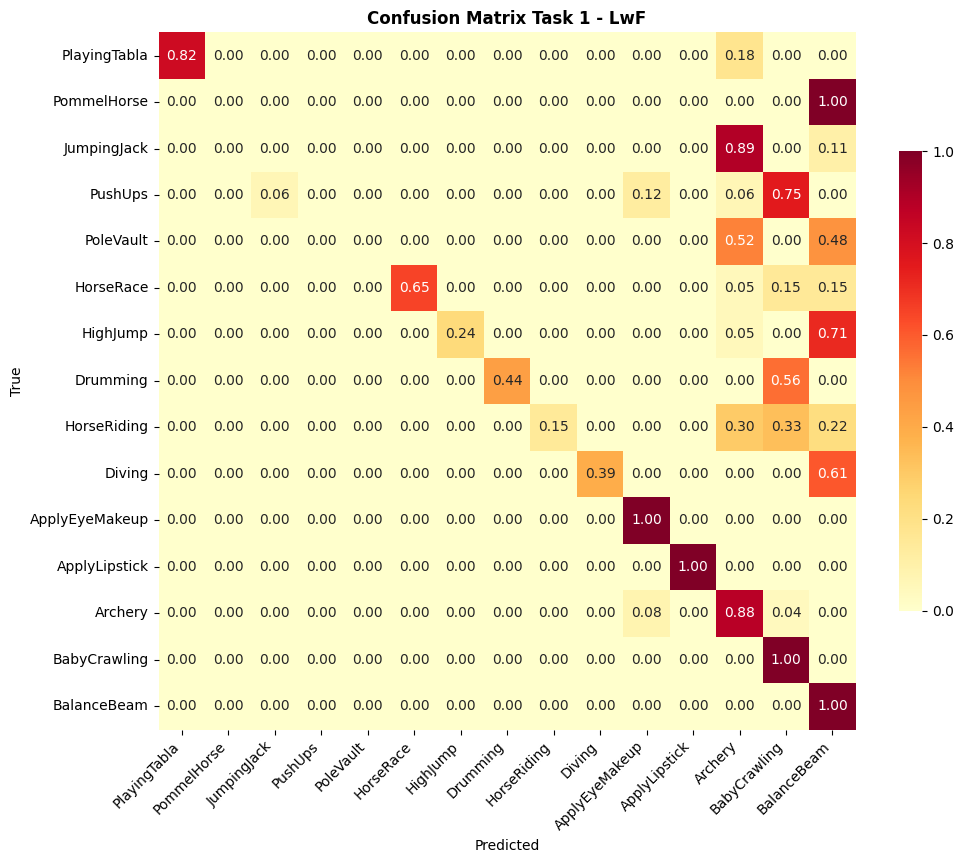

In [21]:
_, all_preds, all_labels = test_model(model, combined_test_loader, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 1 - LwF")

### Old vs new classes

In [22]:
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, len(cfg.SELECTED_CLASSES)),
                       split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)))


METRICS FOR 15 CLASSES
  Accuracy : 0.5062
  F1-Score : 0.4583

PER-CLASS REPORT
                precision    recall  f1-score   support

  PlayingTabla       1.00      0.82      0.90        17
   PommelHorse       0.00      0.00      0.00        19
   JumpingJack       0.00      0.00      0.00        19
       PushUps       0.00      0.00      0.00        16
     PoleVault       0.00      0.00      0.00        25
     HorseRace       1.00      0.65      0.79        20
      HighJump       1.00      0.24      0.38        21
      Drumming       1.00      0.44      0.61        25
   HorseRiding       1.00      0.15      0.26        27
        Diving       1.00      0.39      0.56        23
ApplyEyeMakeup       0.86      1.00      0.93        25
 ApplyLipstick       1.00      1.00      1.00        20
       Archery       0.33      0.88      0.48        25
  BabyCrawling       0.37      1.00      0.54        23
   BalanceBeam       0.19      1.00      0.32        17

      accuracy      

## **Task 2**

### Frozen copy of the model

In [23]:
teacher2 = snapshot_teacher(model)

### Label encoding

In [24]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


### Loaders

In [25]:
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test2        = ConcatDataset([base_test, task1_test, task2_test])
combined_test_loader2 = DataLoader(combined_test2, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

### Expand the head

In [26]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

### Before training

In [27]:
results_baseline_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                         [task1_test_loader, task2_test_loader],
                                         [combined_test_loader, combined_test_loader2])

  base             -> Acc=0.2642  Loss=2.0277
  task1_only        -> Acc=0.9727  Loss=0.2648
  task2_only        -> Acc=0.0000  Loss=4.8423
  combined_t1       -> Acc=0.5062  Loss=1.4255
  combined_t2       -> Acc=0.3713  Loss=2.3361


### Training (LwF)

In [28]:
set_seed(cfg.SEED)
track2 = {"Base": base_test_loader, "Task 1": task1_test_loader, "Task 2": task2_test_loader}
train_task2 = train_continual(model, task2_train_loader, task2_val_loader, device,
                              teacher=teacher2, num_old_classes=len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
                              lambda_distill=cfg.LAMBDA_DISTILL, T=cfg.KD_TEMPERATURE,
                              epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                              track_loaders=track2, track_history=forget_hist)

Epoch [1/5] | Train Acc: 0.3101 Loss: 3.2319 | Val Acc: 0.9059 Loss: 0.8924
Epoch [2/5] | Train Acc: 0.8608 Loss: 1.5147 | Val Acc: 0.9529 Loss: 0.3785
Epoch [3/5] | Train Acc: 0.9602 Loss: 1.0930 | Val Acc: 0.9647 Loss: 0.2462
Epoch [4/5] | Train Acc: 0.9841 Loss: 0.8530 | Val Acc: 0.9882 Loss: 0.2069
Epoch [5/5] | Train Acc: 0.9841 Loss: 0.7323 | Val Acc: 0.9882 Loss: 0.1332


### Training curves

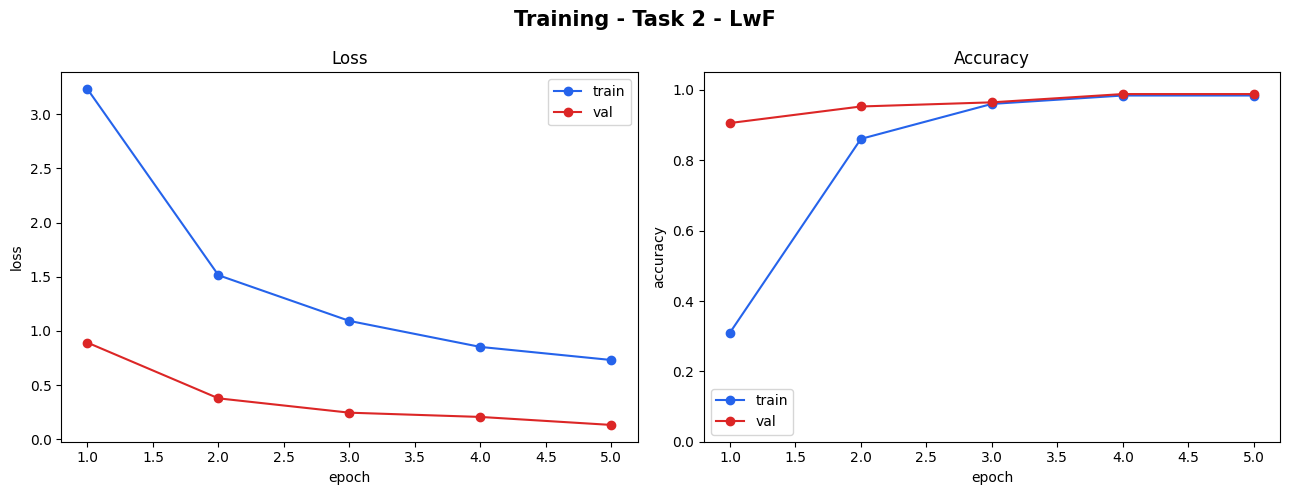

In [29]:
plot_training_results(train_task2, task_name="Task 2 - LwF")

### Evaluate all tasks

In [30]:
results_after_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                      [task1_test_loader, task2_test_loader],
                                      [combined_test_loader, combined_test_loader2])
snapshots.append(results_after_t2)

  base             -> Acc=0.0000  Loss=4.2354
  task1_only        -> Acc=0.1545  Loss=2.1998
  task2_only        -> Acc=1.0000  Loss=0.1901
  combined_t1       -> Acc=0.0528  Loss=3.5400
  combined_t2       -> Acc=0.3052  Loss=2.6472


### Confusion matrix

Test Accuracy: 0.3052


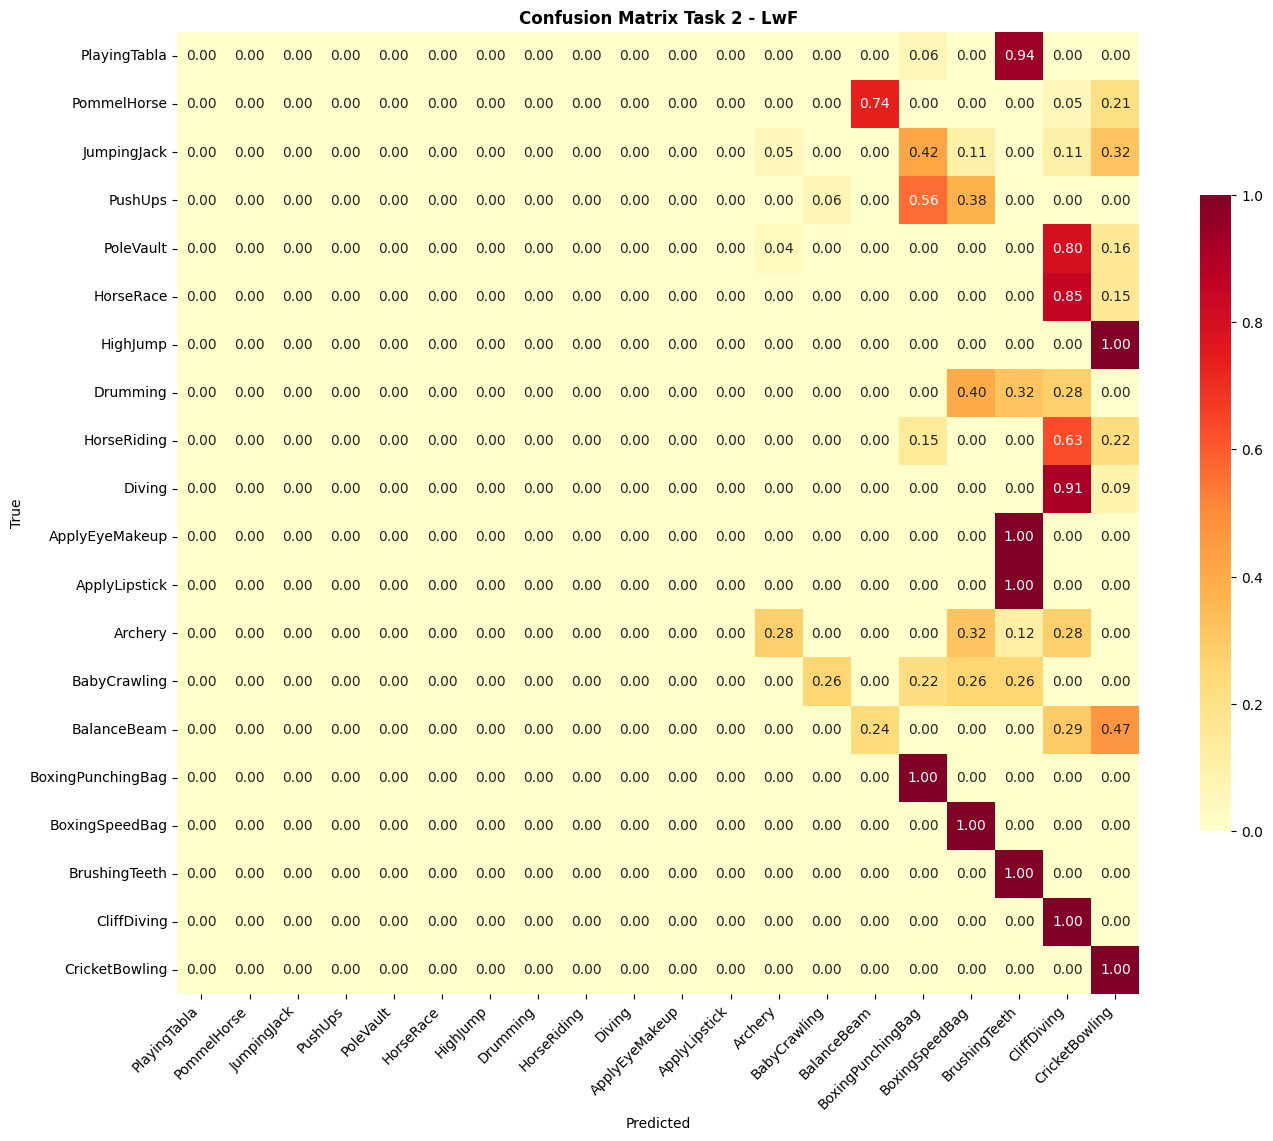

In [31]:
_, all_preds, all_labels = test_model(model, combined_test_loader2, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 2 - LwF")

### Old vs new classes

In [32]:
split_new = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, split_new),
                       split_new=(split_new, len(ALL_CLASSES_LIST)))


METRICS FOR 20 CLASSES
  Accuracy : 0.3052
  F1-Score : 0.1826

PER-CLASS REPORT
                   precision    recall  f1-score   support

     PlayingTabla       0.00      0.00      0.00        17
      PommelHorse       0.00      0.00      0.00        19
      JumpingJack       0.00      0.00      0.00        19
          PushUps       0.00      0.00      0.00        16
        PoleVault       0.00      0.00      0.00        25
        HorseRace       0.00      0.00      0.00        20
         HighJump       0.00      0.00      0.00        21
         Drumming       0.00      0.00      0.00        25
      HorseRiding       0.00      0.00      0.00        27
           Diving       0.00      0.00      0.00        23
   ApplyEyeMakeup       0.00      0.00      0.00        25
    ApplyLipstick       0.00      0.00      0.00        20
          Archery       0.78      0.28      0.41        25
     BabyCrawling       0.86      0.26      0.40        23
      BalanceBeam       0.22    

## **Forgetting**

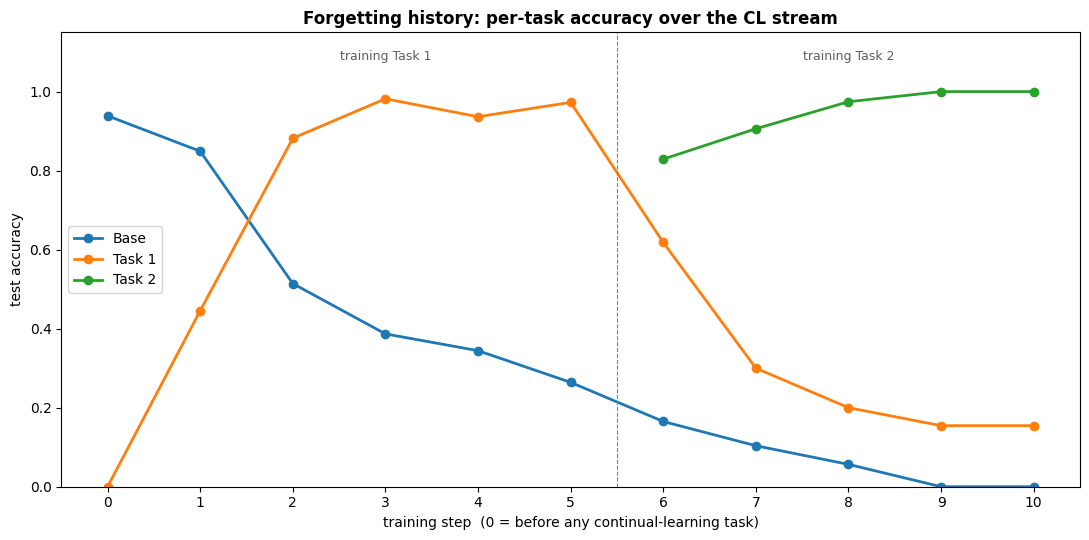

In [33]:
plot_forgetting_history(forget_hist, epochs_per_task=cfg.CL_EPOCHS)

## **Save**

In [34]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"arm": "lwf", "classes": ALL_CLASSES_LIST, "snapshots": snapshots}
with open(f"{cfg.RESULTS_DIR}/stage3_lwf.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage3_lwf.json")

saved -> /content/drive/MyDrive/apai/results/stage3_lwf.json


## **Recap**

- LwF keeps the outputs on the old classes close to those of a frozen copy of the old model. No old clips are stored.
- After Task 2: base 0.0%, Task 1 15.5%, Task 2 100%; all 20 classes 30.5%.
- With one head for all classes the new classes win almost every prediction, so LwF forgets nearly as much as naive fine-tuning.